### Lab No 4 Convolution in Python

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Random discrete-time signals
x = np.random.randint(-3, 4, 7)   # 7-point random signal from -3 to 3
h = np.random.randint(-2, 3, 5)   # 5-point random signal from -2 to 2

In [3]:
print("x[n] =", x)
print("h[n] =", h)

x[n] = [-3  0 -1 -2 -1  1 -2]
h[n] = [ 1 -2 -1 -2 -1]


In [4]:
# Convolution
y = np.convolve(x, h)
print("y[n] =", y)

y[n] = [-3  6  2  6  7  7  2  7  1  3  2]


In [5]:
# Define sample indices
n_x = np.arange(len(x))
n_h = np.arange(len(h))
n_y = np.arange(len(y))

In [9]:
# Plot signals
plt.figure(figsize=(12, 8))

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

Text(0, 0.5, 'Amplitude')

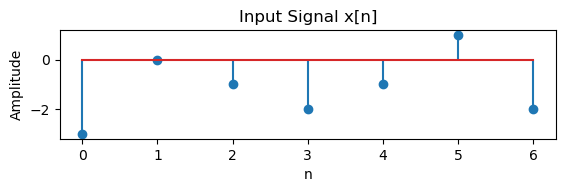

In [10]:
# x[n]
plt.subplot(3, 1, 1)
plt.stem(n_x, x)
plt.title("Input Signal x[n]")
plt.xlabel("n")
plt.ylabel("Amplitude")

Text(0, 0.5, 'Amplitude')

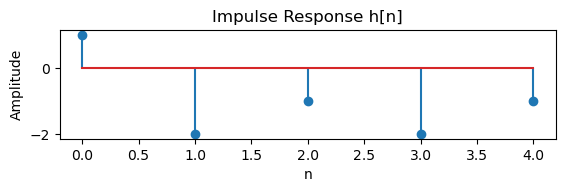

In [11]:
# h[n]
plt.subplot(3, 1, 2)
plt.stem(n_h, h)
plt.title("Impulse Response h[n]")
plt.xlabel("n")
plt.ylabel("Amplitude")

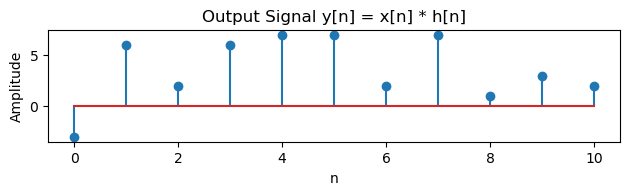

In [12]:
# y[n] = x[n] * h[n]
plt.subplot(3, 1, 3)
plt.stem(n_y, y)
plt.title("Output Signal y[n] = x[n] * h[n]")
plt.xlabel("n")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
L = 5
n = np.arange(-5, 11)  # n from -5 to 10

In [2]:
len(n)

16

In [3]:
# Unit step signal
x = np.where(n >= 0, 1, 0)

In [4]:
x

array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [5]:
# Running sum filter h[n] = 1/L for k=0 to L-1
h = np.ones(L) / L

In [6]:
h

array([0.2, 0.2, 0.2, 0.2, 0.2])

In [7]:
# Convolution (discrete-time)
y = np.convolve(x, h, mode='full')

In [8]:
y

array([0. , 0. , 0. , 0. , 0. , 0.2, 0.4, 0.6, 0.8, 1. , 1. , 1. , 1. ,
       1. , 1. , 1. , 0.8, 0.6, 0.4, 0.2])

In [9]:
# Adjust n index for convolution
n_y = np.arange(2 * n[0], 2 * n[-1] + 1)  # or simply len(y)
n_y = np.arange(-5, -5 + len(y))

In [10]:
n_y


array([-5, -4, -3, -2, -1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11,
       12, 13, 14])

(-0.2, 1.2)

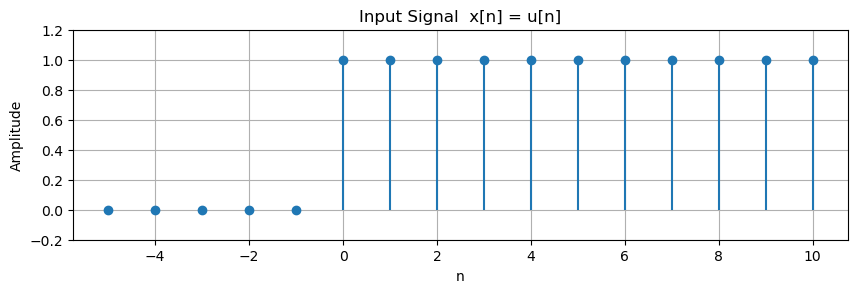

In [12]:
# PLOTS
# ---------------------------
plt.figure(figsize=(10, 6))

# Subplot 1: Input x[n]
plt.subplot(2, 1, 1)
plt.stem(n, x, basefmt=" ")
plt.title("Input Signal  x[n] = u[n]")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)
plt.ylim(-0.2, 1.2)

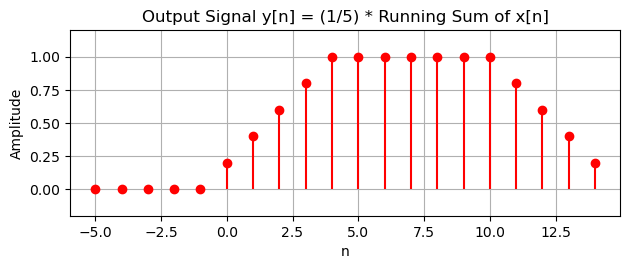

In [13]:
# Subplot 2: Output y[n]
plt.subplot(2, 1, 2)
plt.stem(n_y, y, linefmt='r-', markerfmt='ro', basefmt=" ")
plt.title(f"Output Signal y[n] = (1/{L}) * Running Sum of x[n]")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)
plt.ylim(-0.2, 1.2)

plt.tight_layout()
plt.show()

In [14]:
# Print numerical values for verification
print("n   y[n]")
for ni, yi in zip(n_y, y):
    if -5 <= ni <= 10:
        print(f"{ni:2d}  {yi:.2f}")

n   y[n]
-5  0.00
-4  0.00
-3  0.00
-2  0.00
-1  0.00
 0  0.20
 1  0.40
 2  0.60
 3  0.80
 4  1.00
 5  1.00
 6  1.00
 7  1.00
 8  1.00
 9  1.00
10  1.00


 n | x[n] | y[n]
---+------+-----
 0 |    1 |    2
 1 |    2 |    1
 2 |    3 |    2
 3 |    2 |   -1
 4 |    1 |    2
 5 |    1 |    3
 6 |    1 |    1
 7 |    1 |    1
 8 |    1 |    1
 9 |    1 |    1
10 |    1 |    1


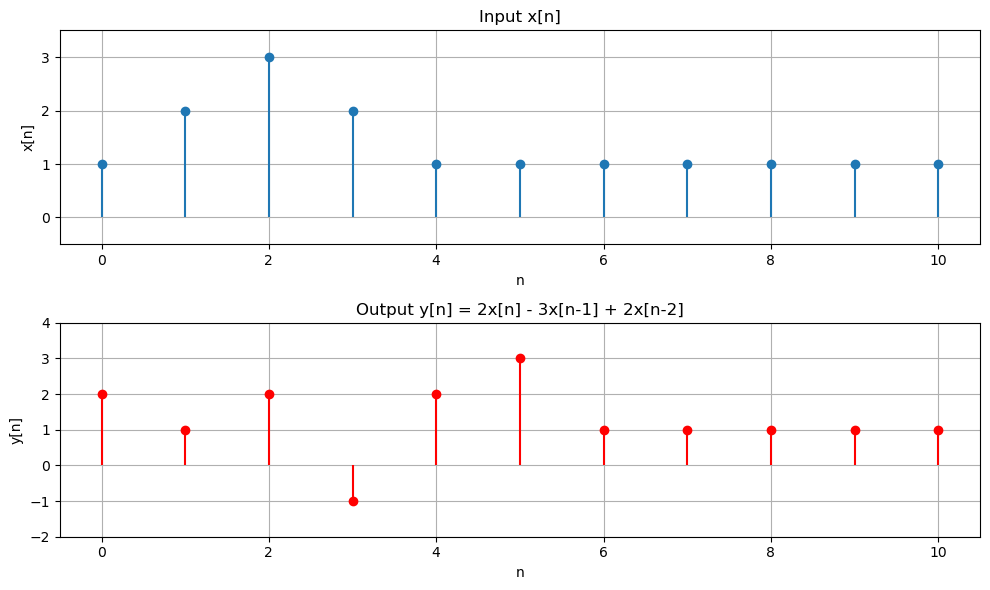


Impulse response h[n]:
h[0] = 2
h[1] = -3
h[2] = 2


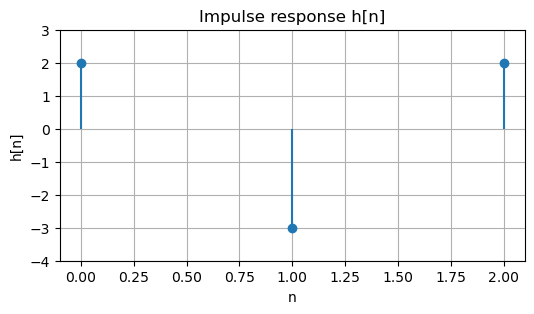

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# --- define x[n] as given ---
def x(n):
    if n < 0:
        return 0
    if n in (0, 1, 2):
        return n + 1
    if n in (3, 4):
        return 5 - n
    # n >= 5
    return 1

# compute for n = 0..10
n = np.arange(0, 11)
x_vals = np.array([x(ii) for ii in n])

# --- compute y[n] using the difference equation ---
# y[n] = 2 x[n] - 3 x[n-1] + 2 x[n-2]
y_vals = []
for ii in n:
    xn   = x(ii)
    xm1  = x(ii-1) if ii-1 >= 0 else 0
    xm2  = x(ii-2) if ii-2 >= 0 else 0
    y = 2*xn - 3*xm1 + 2*xm2
    y_vals.append(y)
y_vals = np.array(y_vals)

# Print numerical results
print(" n | x[n] | y[n]")
print("---+------+-----")
for ii, xv, yv in zip(n, x_vals, y_vals):
    print(f"{ii:2d} | {xv:4d} | {yv:4d}")

# -------------------------
# Plots: x[n] and y[n] (side-by-side)
# -------------------------
plt.figure(figsize=(10,6))

plt.subplot(2,1,1)
plt.stem(n, x_vals, basefmt=" ")
plt.title("Input x[n]")
plt.xlabel("n")
plt.ylabel("x[n]")
plt.grid(True)
plt.ylim(-0.5, max(x_vals)+0.5)

plt.subplot(2,1,2)
plt.stem(n, y_vals, linefmt='r-', markerfmt='ro', basefmt=" ")
plt.title("Output y[n] = 2x[n] - 3x[n-1] + 2x[n-2]")
plt.xlabel("n")
plt.ylabel("y[n]")
plt.grid(True)
plt.ylim(min(y_vals)-1, max(y_vals)+1)

plt.tight_layout()
plt.show()

# -------------------------
# Part (c): impulse response h[n] for x[n]=delta[n]
# h[n] = 2 delta[n] - 3 delta[n-1] + 2 delta[n-2]
# so h[0]=2, h[1]=-3, h[2]=2, others 0
# -------------------------
h_n = np.array([2, -3, 2])
n_h = np.arange(0, len(h_n))

print("\nImpulse response h[n]:")
for ii, hv in zip(n_h, h_n):
    print(f"h[{ii}] = {hv}")

plt.figure(figsize=(6,3))
plt.stem(n_h, h_n, basefmt=" ")
plt.title("Impulse response h[n]")
plt.xlabel("n")
plt.ylabel("h[n]")
plt.grid(True)
plt.ylim(min(h_n)-1, max(h_n)+1)
plt.show()


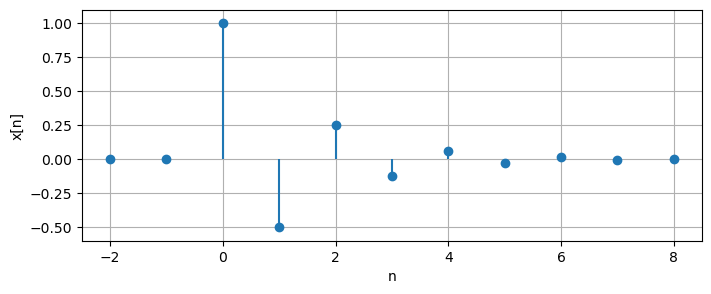

 n |   x[n]       |   y[n]
---+--------------+--------------
-2 |   0.00000000 |   0.00000000
-1 |   0.00000000 |   0.00000000
 0 |   1.00000000 |   1.00000000
 1 |  -0.50000000 |   0.50000000
 2 |   0.25000000 |  -0.25000000
 3 |  -0.12500000 |   0.12500000
 4 |   0.06250000 |  -0.06250000
 5 |  -0.03125000 |   0.03125000
 6 |   0.01562500 |  -0.01562500
 7 |  -0.00781250 |   0.00781250
 8 |   0.00390625 |  -0.00390625


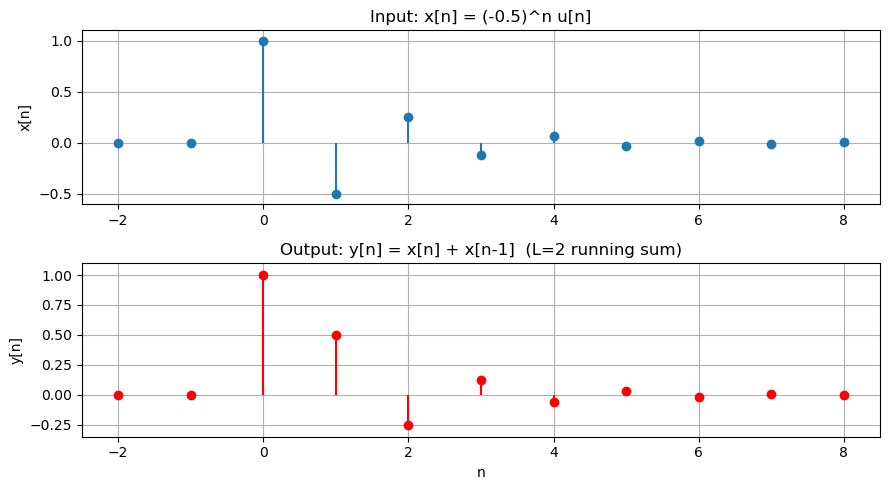

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# range
n = np.arange(-2, 9)   # -2,...,8

# ---- (a) x[n] = (-0.5)^n u[n] ----
x = np.where(n >= 0, (-0.5) ** n, 0.0)

# Plot x[n]
plt.figure(figsize=(8,3))
plt.stem(n, x, basefmt=" ")
#plt.title(r"$x[n]=(-0.5)^n u[n] \quad (-2 \le n \le 8)$")
plt.xlabel("n")
plt.ylabel("x[n]")
plt.grid(True)
plt.ylim(min(x)-0.1, max(x)+0.1)
plt.show()

# ---- (b) L = 2 running-sum: y[n] = x[n] + x[n-1] ----
L = 2
# For L=2, y[n] = sum_{k=0}^{1} x[n-k] = x[n] + x[n-1]
# compute y taking care of x[n-1] when n-1 < -2 (but u makes x<0 zero)
y = np.zeros_like(x)
for i, ni in enumerate(n):
    xn   = x[i]
    xm1  = x[i-1] if i-1 >= 0 else 0.0
    y[i] = xn + xm1

# Print numerical values
print(" n |   x[n]       |   y[n]")
print("---+--------------+--------------")
for ni, xv, yv in zip(n, x, y):
    print(f"{ni:2d} | {xv:12.8f} | {yv:12.8f}")

# Plot x[n] and y[n] side-by-side
plt.figure(figsize=(9,5))

plt.subplot(2,1,1)
plt.stem(n, x, basefmt=" ")
plt.title("Input: x[n] = (-0.5)^n u[n]")
plt.ylabel("x[n]")
plt.grid(True)
plt.ylim(min(x)-0.1, max(x)+0.1)

plt.subplot(2,1,2)
plt.stem(n, y, linefmt='r-', markerfmt='ro', basefmt=" ")
plt.title("Output: y[n] = x[n] + x[n-1]  (L=2 running sum)")
plt.xlabel("n")
plt.ylabel("y[n]")
plt.grid(True)
plt.ylim(min(y)-0.1, max(y)+0.1)

plt.tight_layout()
plt.show()


y[n] = [ 6 17 30 24  6 -4 -5]


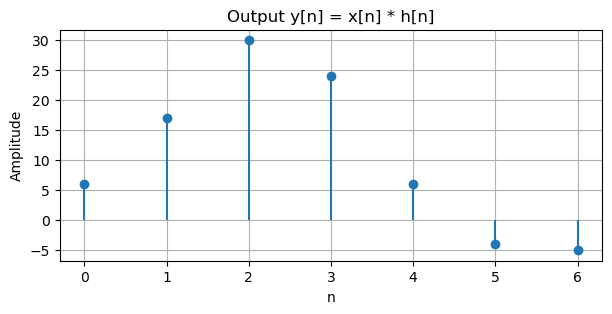

In [21]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([2, 1, -1])
h = np.array([3, 7, 13, 9, 5])
y = np.convolve(x, h)

print("y[n] =", y)

plt.figure(figsize=(7,3))
plt.stem(y, basefmt=" ")
plt.title("Output y[n] = x[n] * h[n]")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


In [23]:
import numpy as np
import matplotlib.pyplot as plt

n = np.arange(-6, 11)                # choose any index range
x = (1 - (-1)**n) / 2                # x[n] = 0 for even, 1 for odd
b = np.array([-10, 10, 10])
# compute y by direct convolution-like formula:
y = -10*x + 10*np.roll(x, 1) + 10*np.roll(x, 2)
# fix values for indices where roll used invalid past values if needed:
# (If you want causal indexing with x[n<min_n]=0, you can compute manually.)

plt.figure(figsize=(8,3))
plt.stem(n, x, basefmt=" ", linefmt='C0-', markerfmt='C0o', label='x[n]')
plt.stem(n, y, basefmt=" ", linefmt='C1--', markerfmt='C1s', label='y[n]')
plt.xlabel('n')
plt.legend()
plt.grid(True)
plt.title('Input x[n] (odd=1) and output y[n]')
plt.show()


ValueError: Integers to negative integer powers are not allowed.